In [1]:
%pip install librosa numpy pandas matplotlib scikit-learn seaborn

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 6.1 MB/s  0:00:00

   ------ --------------------------------- 1/6 [msgpack]
   ------------- -------------------------- 2/6 [audioread]
   ------------- -------------------------- 2/6 [audioread]
   -------------------- ------------------- 3/6 [soundfile]
   -------------------------- ------------- 4/6 [pooch]
   -------------------------- ------------- 4/6 [pooch]
   -------------------------- ------------- 4/6 [pooch]
   -------------------------- ------------- 4/6 [pooch]
   -------------------------- ------------- 4/6 [pooch]
   -------------------------- ------------- 4/6 [pooch]
   --------------------------------- ------ 5/6 [librosa]
   --------------------------------- ------ 5/6 [librosa]
   --------------------------------- ------ 5/6 [librosa]
   --------------------------------- ------ 5/6 [librosa]
   --------------------------------- ------ 5/6 [li


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("default")


In [3]:
dataset_path = r"C:\Users\vikra\OneDrive\Desktop\New folder\SEM 6\ATSA-CASE-STUDY\archive"

In [24]:
def extract_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)
    
    # MFCC
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    
    # Delta & Delta-Delta
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    
    # ZCR
    zcr = librosa.feature.zero_crossing_rate(signal)
    
    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)
    
    # RMS Energy
    rms = librosa.feature.rms(y=signal)
    
    # Fast Pitch
    pitches, magnitudes = librosa.piptrack(y=signal, sr=sr)
    pitch = pitches[pitches > 0]
    
    if len(pitch) == 0:
        pitch_mean = 0
        pitch_std = 0
    else:
        pitch_mean = np.mean(pitch)
        pitch_std = np.std(pitch)
    
    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(delta_mfcc, axis=1),
        np.std(delta_mfcc, axis=1),
        np.mean(delta2_mfcc, axis=1),
        np.std(delta2_mfcc, axis=1),
        np.mean(zcr),
        np.std(zcr),
        np.mean(spectral_centroid),
        np.std(spectral_centroid),
        np.mean(rms),
        np.std(rms),
        pitch_mean,
        pitch_std
    ])
    
    return features


In [26]:
X = []
y = []
actors = []

for actor_folder in os.listdir(dataset_path):
    
    # Only process folders that start with "Actor_"
    if not actor_folder.startswith("Actor_"):
        continue
    
    actor_path = os.path.join(dataset_path, actor_folder)
    
    if os.path.isdir(actor_path):
        
        actor_id = int(actor_folder.split("_")[1])
        
        for file in os.listdir(actor_path):
            
            if file.endswith(".wav"):
                
                emotion_code = int(file.split("-")[2])
                
                if emotion_code in [1, 2]:
                    label = 0
                elif emotion_code in [5, 6]:
                    label = 1
                else:
                    continue
                
                file_path = os.path.join(actor_path, file)
                features = extract_features(file_path)
                
                X.append(features)
                y.append(label)
                actors.append(actor_id)

X = np.array(X)
y = np.array(y)
actors = np.array(actors)

print("Feature Shape:", X.shape)
print("Normal:", np.sum(y==0))
print("Stressed:", np.sum(y==1))


Feature Shape: (672, 86)
Normal: 288
Stressed: 384


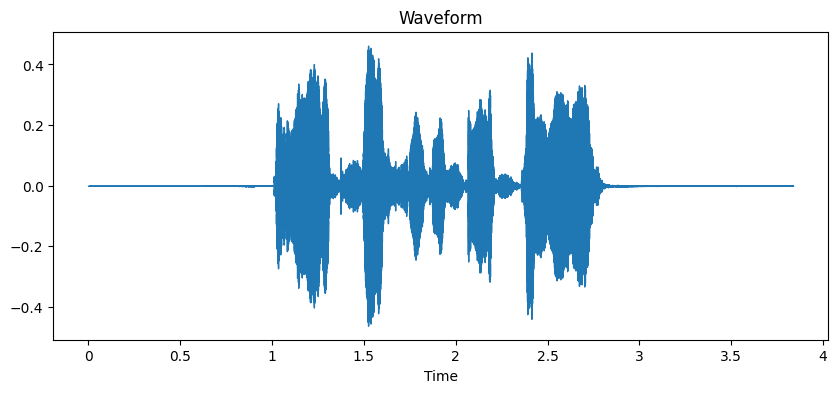

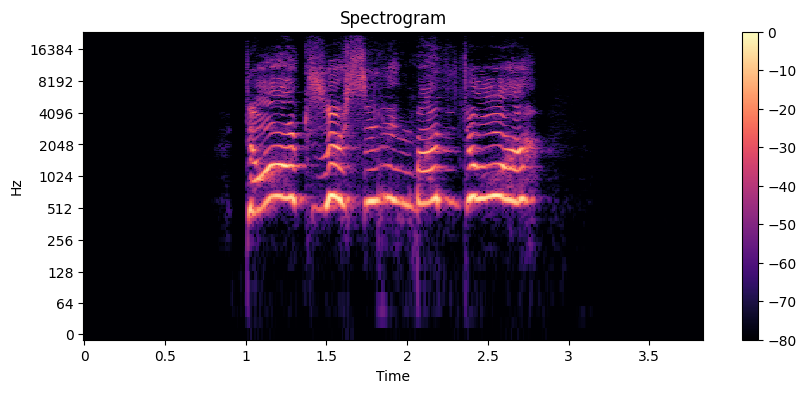

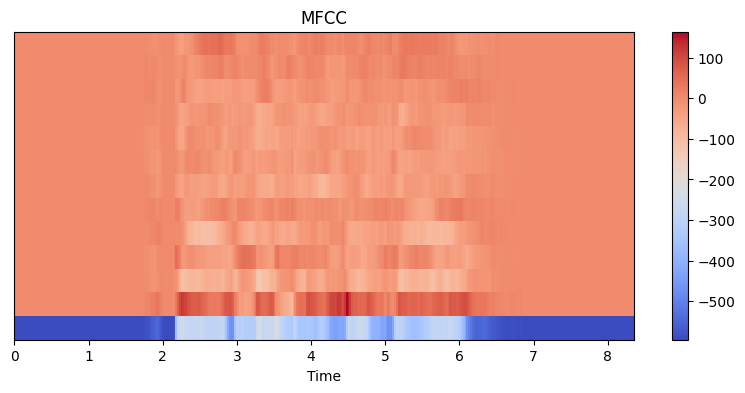

In [27]:
sample_file = file_path
signal, sr = librosa.load(sample_file, sr=None)

# Waveform
plt.figure(figsize=(10,4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Waveform")
plt.show()

# Spectrogram
D = np.abs(librosa.stft(signal))
plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max),
                         sr=sr, x_axis='time', y_axis='log')
plt.title("Spectrogram")
plt.colorbar()
plt.show()

# MFCC
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.title("MFCC")
plt.colorbar()
plt.show()


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm_model = SVC(kernel='rbf')

scores = cross_val_score(svm_model, X_scaled, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Std Deviation:", np.std(scores))


Cross Validation Scores: [0.91851852 0.8962963  0.87313433 0.94029851 0.85074627]
Mean Accuracy: 0.8957987838584854
Std Deviation: 0.031749223397204616


In [29]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_scaled, y)

rf_scores = cross_val_score(rf_model, X_scaled, y, cv=5)

print("Random Forest CV Accuracy:", np.mean(rf_scores))


Random Forest CV Accuracy: 0.8735655058043118


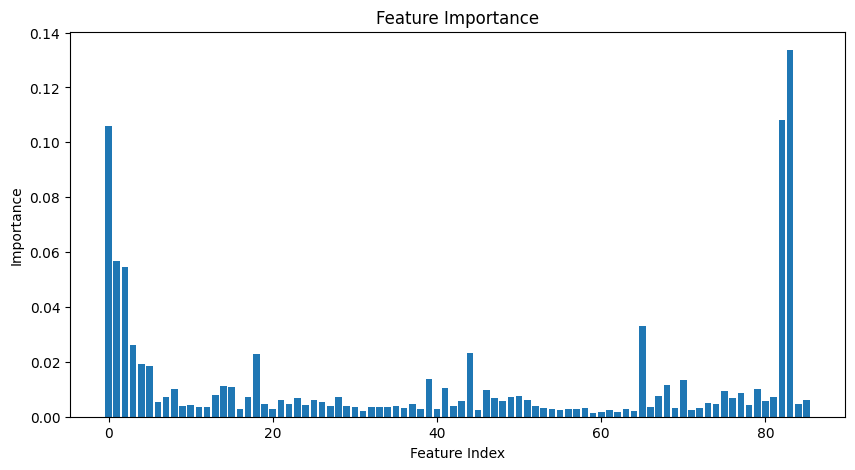

In [30]:
importances = rf_model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [32]:
train_idx = actors <= 14
test_idx = actors > 14

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actor-wise Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Actor-wise Accuracy: 0.875

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       120
           1       0.86      0.93      0.89       160

    accuracy                           0.88       280
   macro avg       0.88      0.87      0.87       280
weighted avg       0.88      0.88      0.87       280



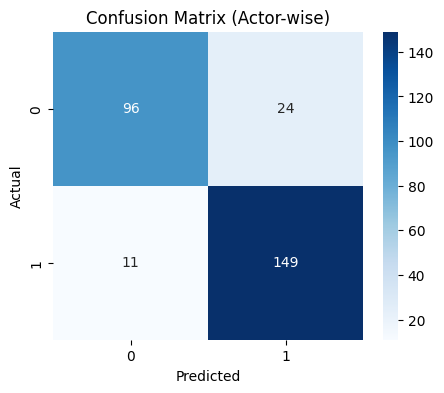

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Actor-wise)")
plt.show()

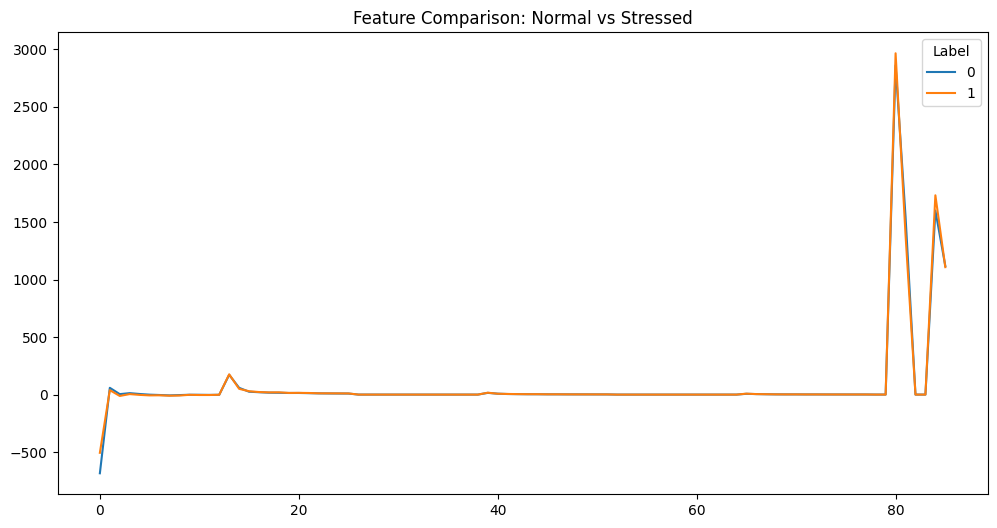

In [34]:
df = pd.DataFrame(X)
df["Label"] = y

mean_features = df.groupby("Label").mean()

mean_features.T.plot(figsize=(12,6))
plt.title("Feature Comparison: Normal vs Stressed")
plt.show()